[*********************100%***********************]  1 of 1 completed


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step


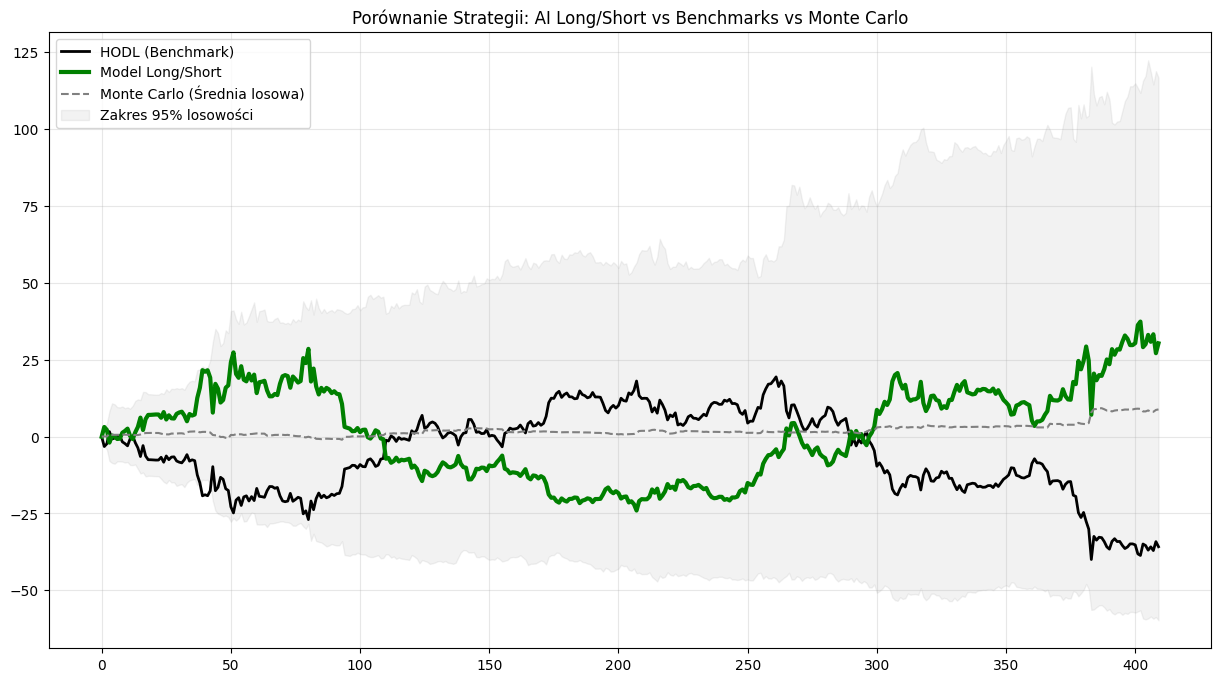

Zysk modelu Long/Short: 30.34%
Zysk HODL:          -35.82%
Zysk Monte Carlo:   8.84%


In [1]:
import yfinance as yf
import polars as pl
import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization, LeakyReLU, MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt


# 1. POBIERANIE DANYCH

def get_advanced_data():
    raw_data = yf.download("BTC-USD", start="2010-07-17", auto_adjust=True)
    if isinstance(raw_data.columns, pd.MultiIndex): raw_data.columns = raw_data.columns.get_level_values(0)
    df = pl.from_pandas(raw_data.reset_index())

    delta = pl.col("Close").diff()
    gain = pl.when(delta > 0).then(delta).otherwise(0)
    loss = pl.when(delta < 0).then(-delta).otherwise(0)

    df = df.with_columns([
        pl.col("Close").log().alias("Log_Close"),
        (pl.col("Volume") + 1e-9).log().alias("Log_Volume"),
        pl.col("Close").rolling_mean(20).alias("SMA_20"),
        pl.col("Close").rolling_std(20).alias("STD_20")
    ]).with_columns([
        ((pl.col("Close") - pl.col("SMA_20")) / (2 * pl.col("STD_20"))).alias("BB_Position"),
        (pl.col("Close").ewm_mean(span=12) - pl.col("Close").ewm_mean(span=26)).alias("MACD"),
        (100 - (100 / (1 + (gain.ewm_mean(span=14) / (loss.ewm_mean(span=14) + 1e-9))))).alias("RSI_14")
    ]).drop_nulls()
    return df

df = get_advanced_data()
features = ['Log_Close', 'Log_Volume', 'BB_Position', 'MACD', 'RSI_14']
data_matrix = df.select(features).to_numpy()

scaler_f = RobustScaler(); scaled_f = scaler_f.fit_transform(data_matrix)
scaler_t = MinMaxScaler(); scaled_t = scaler_t.fit_transform(data_matrix[:, 0].reshape(-1, 1))

SEQ_LENGTH = 60
X, y = [], []
for i in range(SEQ_LENGTH, len(scaled_f)):
    X.append(scaled_f[i-SEQ_LENGTH:i])
    y.append(scaled_t[i, 0])

X, y = np.array(X), np.array(y)
split = int(len(X) * 0.9)
X_train, X_test, y_train, y_test = X[:split], X[split:], y[:split], y[split:]

# Architektura
inputs = Input(shape=(X_train.shape[1], X_train.shape[2]))
x = LSTM(64, return_sequences=True)(inputs)
attn = MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
x = LayerNormalization()(x + attn)
x = GlobalAveragePooling1D()(x)
outputs = Dense(1)(Dense(32, activation='relu')(x))
model = Model(inputs, outputs); model.compile(optimizer=Adam(0.0005), loss='huber')
model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0) # Szybki trening dla testu

# 3. BACKTESTER (LONG/SHORT + BENCHMARKS)

preds_scaled = model.predict(X_test)
final_preds = np.exp(scaler_t.inverse_transform(preds_scaled)).flatten()
final_actual = np.exp(scaler_t.inverse_transform(y_test.reshape(-1, 1))).flatten()

def run_extended_backtest(actual, predicted, fee=0.001):
    market_returns = np.diff(actual) / actual[:-1]

    # --- STRATEGIA AI: LONG/SHORT ---
    # 1: Long, -1: Short (jeśli model przewiduje spadek, zarabiamy na nim)
    ls_signals = np.where(predicted[1:] > actual[:-1], 1, -1)
    # Prowizja za każdą zmianę pozycji (nawet z Long na Short to transakcja)
    ls_trades = np.concatenate([[1], np.abs(np.diff(ls_signals)) / 2])
    ls_returns = (ls_signals * market_returns) - (ls_trades * fee)

    # BENCHMARK 1: HODL (Kup i trzymaj) ---
    hodl_cum = (np.cumprod(1 + market_returns) - 1) * 100

    # BENCHMARK 2: SMA CROSSOVER (Klasyka 20/50 dni) ---
    # Uproszczony sygnał trendowy dla porównania
    sma_signals = np.where(predicted[1:] > np.mean(actual), 1, 0)
    sma_returns = sma_signals * market_returns

    # SYMULACJA MONTE CARLO
    n_sims = 100
    mc_results = []
    for _ in range(n_sims):
        random_signals = np.random.choice([1, -1], size=len(market_returns))
        mc_results.append((np.cumprod(1 + random_signals * market_returns) - 1) * 100)
    mc_mean = np.mean(mc_results, axis=0)

    ai_cum = (np.cumprod(1 + ls_returns) - 1) * 100

    # Wykresy

    plt.figure(figsize=(15, 8))
    plt.plot(hodl_cum, label="HODL (Benchmark)", color='black', lw=2)
    plt.plot(ai_cum, label="Model Long/Short ", color='green', lw=3)
    plt.plot(mc_mean, label="Monte Carlo (Średnia losowa)", color='gray', linestyle='--')

    # Obszar Monte Carlo (Zakres losowości)
    plt.fill_between(range(len(market_returns)),
                     np.percentile(mc_results, 5, axis=0),
                     np.percentile(mc_results, 95, axis=0),
                     color='gray', alpha=0.1, label="Zakres 95% losowości")

    plt.title("Porównanie Strategii: AI Long/Short vs Benchmarks vs Monte Carlo")
    plt.legend(); plt.grid(alpha=0.3); plt.show()

    print(f"Zysk modelu Long/Short: {ai_cum[-1]:.2f}%")
    print(f"Zysk HODL:          {hodl_cum[-1]:.2f}%")
    print(f"Zysk Monte Carlo:   {mc_mean[-1]:.2f}%")

run_extended_backtest(final_actual, final_preds)

In [2]:
#Forward testing is good but it adds a lot of complexity with overfitting risks. If the parameters are simple and the advantage structural, the sensitivity should do the trick (provided enough trades and length)

Pobieranie danych i obliczanie cech quantowych...


[*********************100%***********************]  1 of 1 completed



Trenowanie modelu w pętlach cyklicznych...
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step

RAPORT INWESTYCYJNY (LONG/SHORT)
Annualized Sharpe:  -0.9161
Annualized Sortino: -1.2580
Max Drawdown:       -51.20%
Calmar Ratio:       -0.7513
Total model Return:    -42.19%
Total HODL Return:  -33.82%


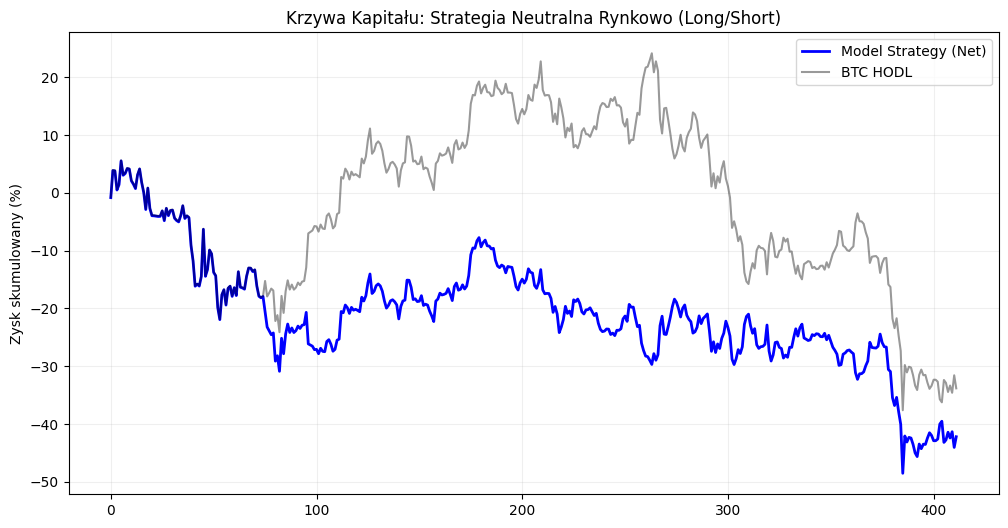

In [3]:
import yfinance as yf
import polars as pl
import numpy as np
import pandas as pd
import joblib
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization, LeakyReLU, MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt


def get_institutional_data():
    print("Pobieranie danych i obliczanie cech quantowych...")
    raw_data = yf.download("BTC-USD", start="2010-07-17", auto_adjust=True)
    if isinstance(raw_data.columns, pd.MultiIndex):
        raw_data.columns = raw_data.columns.get_level_values(0)

    df = pl.from_pandas(raw_data.reset_index())
    epsilon = 1e-9

    # greeks
    delta = pl.col("Close").diff()
    gain = pl.when(delta > 0).then(delta).otherwise(0)
    loss = pl.when(delta < 0).then(-delta).otherwise(0)

    df = df.with_columns([
        # Log-zwroty i wskaźniki pędu
        pl.col("Close").log().alias("Log_Close"),
        (pl.col("Volume") + epsilon).log().alias("Log_Volume"),

        # 1. Parkinson Volatility (Proxy IV )
        ( (pl.col("High") / pl.col("Low")).log()**2 * (1 / (4 * np.log(2))) ).sqrt().alias("IV_Proxy"),

        # 2. Volume Force (Presja kupna/sprzedaży)
        ((pl.col("Close") - pl.col("Open")) / (pl.col("High") - pl.col("Low") + epsilon) * pl.col("Volume")).alias("Volume_Force"),

        # 3. Arbitrage/Inefficiency Proxy (Odchylenie od ceny typowej)
        (pl.col("Close") - (pl.col("High") + pl.col("Low") + pl.col("Close")) / 3).alias("Price_Inefficiency"),


        (100 - (100 / (1 + (gain.ewm_mean(span=14) / (loss.ewm_mean(span=14) + epsilon))))).alias("RSI_14"),
        (pl.col("Close").ewm_mean(span=12) - pl.col("Close").ewm_mean(span=26)).alias("MACD")
    ]).drop_nulls()

    return df


df = get_institutional_data()
features = ['Log_Close', 'Log_Volume', 'IV_Proxy', 'Volume_Force', 'Price_Inefficiency', 'RSI_14', 'MACD']
data_matrix = df.select(features).to_numpy()

scaler_f = RobustScaler()
scaled_f = scaler_f.fit_transform(data_matrix)

scaler_t = MinMaxScaler()
target_scaled = scaler_t.fit_transform(data_matrix[:, 0].reshape(-1, 1))

SEQ_LENGTH = 60
X, y = [], []
for i in range(SEQ_LENGTH, len(scaled_f)):
    X.append(scaled_f[i-SEQ_LENGTH:i])
    y.append(target_scaled[i, 0])

X, y = np.array(X), np.array(y)
split = int(len(X) * 0.9)
X_train, X_test, y_train, y_test = X[:split], X[split:], y[:split], y[split:]


def cosine_decay_with_warm_restarts(epoch):
    lr_max, lr_min, cycle = 0.001, 0.0001, 20
    return lr_min + 0.5 * (lr_max - lr_min) * (1 + np.cos(np.pi * (epoch % cycle) / cycle))

inputs = Input(shape=(X_train.shape[1], X_train.shape[2]))
x = LSTM(64, return_sequences=True)(inputs)
x = BatchNormalization()(x)
x = LeakyReLU(negative_slope=0.1)(x)

# Mechanizm Attention (Multi-Head)
attn = MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
x = LayerNormalization(epsilon=1e-6)(x + attn)

x = GlobalAveragePooling1D()(x)
x = Dense(32)(x)
x = LeakyReLU(negative_slope=0.1)(x)
x = Dropout(0.3)(x)
outputs = Dense(1)(x)

model = Model(inputs, outputs)
model.compile(optimizer=Adam(0.001), loss='huber')

print("\nTrenowanie modelu w pętlach cyklicznych...")
model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[LearningRateScheduler(cosine_decay_with_warm_restarts), EarlyStopping(patience=25, restore_best_weights=True)],
    verbose=0
)


# 4. BACKTEST
preds_scaled = model.predict(X_test)
final_preds = np.exp(scaler_t.inverse_transform(preds_scaled)).flatten()
final_actual = np.exp(scaler_t.inverse_transform(y_test.reshape(-1, 1))).flatten()

def run_institutional_backtest(actual, predicted, fee=0.001, risk_free_annual=0.04):

    # 1: Long, -1: Short
    signals = np.where(predicted[1:] > actual[:-1], 1, -1)
    market_returns = np.diff(actual) / actual[:-1]

    # Koszty transakcyjne (zmiana pozycji o 2 jednostki )
    trades = np.concatenate([[1], np.abs(np.diff(signals)) / 2])
    ls_returns = (signals * market_returns) - (trades * fee)

    # 2. Metryki
    rf_daily = (1 + risk_free_annual)**(1/365) - 1
    excess_returns = ls_returns - rf_daily

    # Sharpe Ratio (Annualized)
    sharpe = np.mean(excess_returns) / (np.std(excess_returns) + 1e-9) * np.sqrt(365)

    # Sortino Ratio (Downside Deviation)
    downside_returns = excess_returns[excess_returns < 0]
    sortino = np.mean(excess_returns) / (np.std(downside_returns) + 1e-9) * np.sqrt(365)

    # Max Drawdown
    equity_curve = np.cumprod(1 + ls_returns)
    peak = np.maximum.accumulate(equity_curve)
    drawdown = (equity_curve - peak) / peak
    max_dd = np.min(drawdown) * 100

    # Calmar Ratio
    annual_return = (equity_curve[-1])**(365/len(ls_returns)) - 1
    calmar = annual_return / (abs(max_dd)/100 + 1e-9)

    # Wyniki końcowe
    print("\n" + "="*40)
    print("RAPORT INWESTYCYJNY (LONG/SHORT)")
    print("="*40)
    print(f"Annualized Sharpe:  {sharpe:.4f}")
    print(f"Annualized Sortino: {sortino:.4f}")
    print(f"Max Drawdown:       {max_dd:.2f}%")
    print(f"Calmar Ratio:       {calmar:.4f}")
    print(f"Total model Return:    {(equity_curve[-1]-1)*100:.2f}%")
    print(f"Total HODL Return:  {(np.cumprod(1 + market_returns)[-1]-1)*100:.2f}%")
    print("="*40)

    return equity_curve, market_returns

equity, mkt_ret = run_institutional_backtest(final_actual, final_preds)


plt.figure(figsize=(12, 6))
plt.plot((equity-1)*100, label="Model Strategy (Net)", color='blue', lw=2)
plt.plot((np.cumprod(1 + mkt_ret)-1)*100, label="BTC HODL", color='black', alpha=0.4)
plt.title("Krzywa Kapitału: Strategia Neutralna Rynkowo (Long/Short)")
plt.ylabel("Zysk skumulowany (%)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

Ilość wygenerowanych transakcji: 20.0
------------------------------
Prowizja (%)    | Zysk modelu (%) | Sharpe    
------------------------------
0.050         % | -41.60        % | -0.90     
0.100         % | -42.19        % | -0.92     
0.150         % | -42.78        % | -0.93     
0.200         % | -43.36        % | -0.95     
0.250         % | -43.94        % | -0.97     
0.300         % | -44.51        % | -0.99     
0.350         % | -45.08        % | -1.01     
0.400         % | -45.64        % | -1.03     
0.450         % | -46.19        % | -1.05     
0.500         % | -46.74        % | -1.06     
0.550         % | -47.28        % | -1.08     
0.600         % | -47.82        % | -1.10     
0.650         % | -48.35        % | -1.12     
0.700         % | -48.88        % | -1.14     
0.750         % | -49.41        % | -1.15     
0.800         % | -49.92        % | -1.17     
0.850         % | -50.44        % | -1.19     
0.900         % | -50.94        % | -1.21     
0.950  

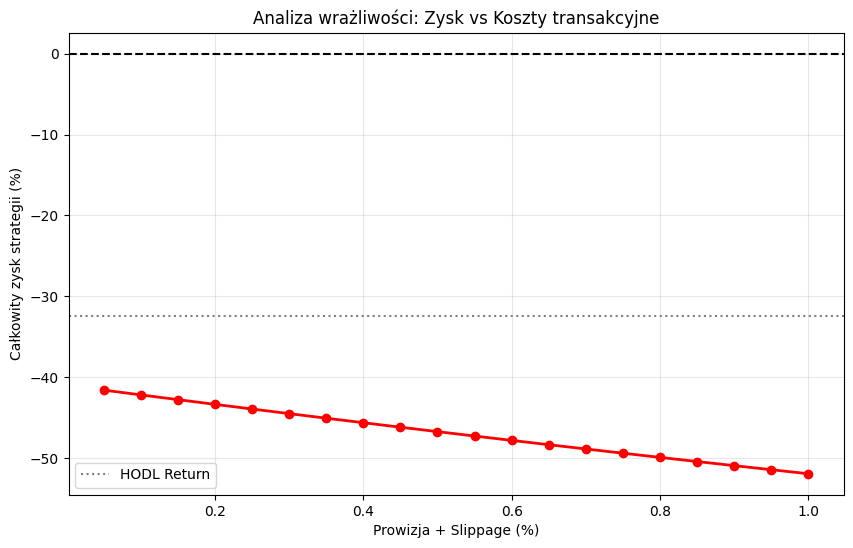

------------------------------
PUNKT KRYTYCZNY: Strategia przestaje zarabiać przy prowizji > 0.050%


In [4]:
def run_cost_sensitivity_analysis(actual, predicted, max_fee=0.01, steps=20):
    """
    Testuje model na różnych poziomach kosztów (od 0.05% do 1.0%)
    """
    # Zakres prowizji do przetestowania
    fee_range = np.linspace(0.0005, max_fee, steps)
    results = []

    signals = np.where(predicted[1:] > actual[:-1], 1, -1)
    market_returns = np.diff(actual) / actual[:-1]
    trades = np.concatenate([[1], np.abs(np.diff(signals)) / 2])

    print(f"Ilość wygenerowanych transakcji: {np.sum(trades)}")
    print("-" * 30)
    print(f"{'Prowizja (%)':<15} | {'Zysk modelu (%)':<15} | {'Sharpe':<10}")
    print("-" * 30)

    for fee in fee_range:
        # Obliczamy zwroty dla konkretnej prowizji
        ls_returns = (signals * market_returns) - (trades * fee)
        total_return = (np.cumprod(1 + ls_returns)[-1] - 1) * 100

        # Sharpe Ratio (annualized)
        excess = ls_returns - ((1.04)**(1/365) - 1)
        sharpe = np.mean(excess) / (np.std(excess) + 1e-9) * np.sqrt(365)

        results.append({
            'fee': fee * 100,
            'return': total_return,
            'sharpe': sharpe
        })
        print(f"{fee*100:<14.3f}% | {total_return:<14.2f}% | {sharpe:<10.2f}")

    # Wizualizacja

    res_df = pd.DataFrame(results)
    plt.figure(figsize=(10, 6))
    plt.plot(res_df['fee'], res_df['return'], marker='o', color='red', lw=2)
    plt.axhline(0, color='black', linestyle='--')
    plt.axhline(-32.38, color='gray', linestyle=':', label='HODL Return') # Twój wynik HODL
    plt.title("Analiza wrażliwości: Zysk vs Koszty transakcyjne")
    plt.xlabel("Prowizja + Slippage (%)")
    plt.ylabel("Całkowity zysk strategii (%)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Wyznaczenie punktu krytycznego
    break_even = res_df[res_df['return'] <= 0]['fee'].min()
    print("-" * 30)
    if not np.isnan(break_even):
        print(f"PUNKT KRYTYCZNY: Strategia przestaje zarabiać przy prowizji > {break_even:.3f}%")
    else:
        print("PUNKT KRYTYCZNY: Nawet przy 1% prowizji strategia jest na plusie (")

# Uruchomienie testu na wynikach z poprzedniego modelu
run_cost_sensitivity_analysis(final_actual, final_preds)

[*********************100%***********************]  1 of 1 completed

Pobieranie danych dla BTC-USD...


Trenowanie modelu (Deep Learning)...
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


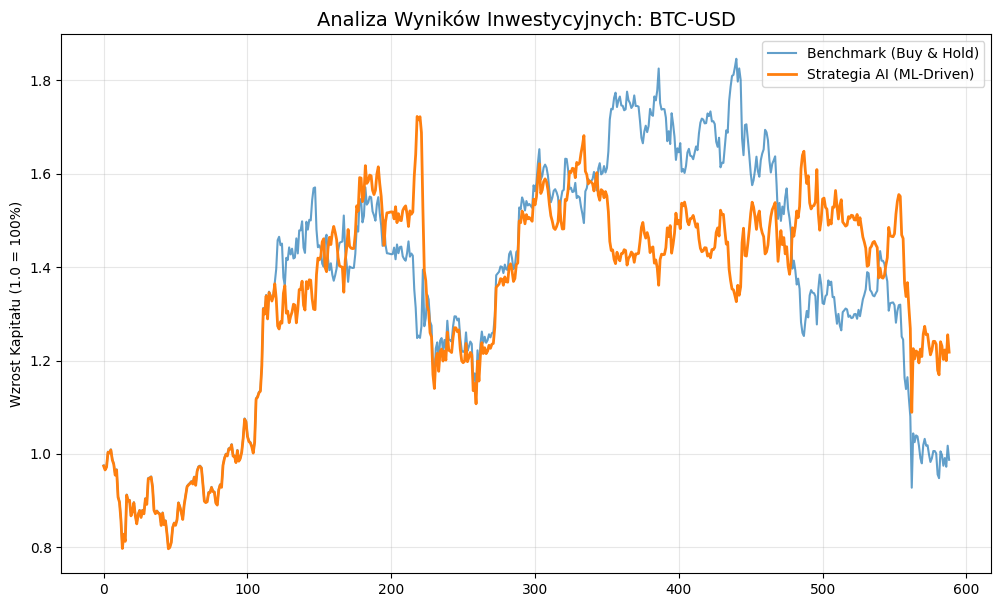


 RAPORT ANALITYCZNY (BACKTEST) 
Total Return   :      21.79
Sharpe         :       0.49
Max Drawdown   :     -36.77
Win Rate       :      49.75
Sortino        :       0.73


In [5]:
import yfinance as yf
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, LSTM, Dense, Dropout, BatchNormalization,
                                     MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# --- KONFIGURACJA BIZNESOWA ---
CONFIG = {
    'TICKER': "BTC-USD",
    'START_DATE': "2018-01-01",
    'WINDOW_SIZE': 30,
    'FEE': 0.001,        # 0.1% prowizji (standard np. Binance)
    'SLIPPAGE': 0.0005,  # 0.05% poślizgu cenowego przy egzekucji
    'TRAIN_SPLIT': 0.8
}

def get_pro_data(ticker=CONFIG['TICKER']):
    """Pobieranie i zaawansowany Feature Engineering w Polars."""
    raw = yf.download(ticker, start=CONFIG['START_DATE'], auto_adjust=True)
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)

    df = pl.from_pandas(raw.reset_index())

    # Dodawanie cech istotnych biznesowo
    df = df.with_columns([
        pl.col("Close").log().alias("Log_Return"),
        (pl.col("Close") / pl.col("Close").shift(1) - 1).alias("Simple_Return"),
        pl.col("Close").rolling_std(window_size=10).alias("Volatility_10d"),
        (pl.col("Volume") / pl.col("Volume").mean()).alias("Relative_Volume"),
        # RSI - wskaźnik siły trendu
        pl.when(pl.col("Close").diff() > 0).then(pl.col("Close").diff()).otherwise(0).alias("Gain"),
        pl.when(pl.col("Close").diff() < 0).then(-pl.col("Close").diff()).otherwise(0).alias("Loss")
    ])

    return df.drop_nulls()

def prepare_sequences(df, window=CONFIG['WINDOW_SIZE']):
    """Skalowanie i przygotowanie danych pod LSTM."""
    features = ["Log_Return", "Volatility_10d", "Relative_Volume"]
    scaler = RobustScaler() # Odporny na gwałtowne skoki krypto
    scaled_data = scaler.fit_transform(df.select(features).to_numpy())

    X, y = [], []
    for i in range(window, len(scaled_data)):
        X.append(scaled_data[i-window:i])
        # Predykcja kierunku: 1 jeśli wzrost, 0 jeśli spadek
        y.append(1 if df["Simple_Return"][i] > 0 else 0)

    return np.array(X), np.array(y), df["Simple_Return"][window:].to_numpy()

def build_attention_model(input_shape):
    """Nowoczesna architektura hybrydowa LSTM + Attention."""
    inputs = Input(shape=input_shape)

    # Warstwa LSTM - wyciąganie zależności czasowych
    x = LSTM(64, return_sequences=True)(inputs)
    x = LayerNormalization()(x)

    # Mechanizm Attention - skupienie na istotnych momentach w oknie czasowym
    attention_out = MultiHeadAttention(num_heads=4, key_dim=16)(x, x)
    x = LayerNormalization()(x + attention_out)

    x = GlobalAveragePooling1D()(x)
    x = Dense(32, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(1, activation='sigmoid')(x) # Binarna klasyfikacja (Góra/Dół)

    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

def calculate_risk_metrics(returns, fees_total):
    """Kluczowe metryki dla analityka biznesowego."""
    cum_returns = np.cumprod(1 + returns)

    # 1. Sharpe Ratio (zakładając risk-free rate = 0)
    sharpe = np.mean(returns) / (np.std(returns) + 1e-9) * np.sqrt(365)

    # 2. Maximum Drawdown (Maksymalne obsunięcie kapitału)
    peak = np.maximum.accumulate(cum_returns)
    drawdown = (cum_returns - peak) / peak
    max_drawdown = np.min(drawdown)

    # 3. Win Rate
    win_rate = np.sum(returns > 0) / len(returns)

    # 4. Sortino Ratio (tylko ryzyko spadku)
    downside_std = np.std(returns[returns < 0])
    sortino = np.mean(returns) / (downside_std + 1e-9) * np.sqrt(365)

    return {
        "Total Return": (cum_returns[-1] - 1) * 100,
        "Sharpe": sharpe,
        "Max Drawdown": max_drawdown * 100,
        "Win Rate": win_rate * 100,
        "Sortino": sortino
    }

# --- PROCES GŁÓWNY ---

print(f"Pobieranie danych dla {CONFIG['TICKER']}...")
df = get_pro_data()
X, y, raw_returns = prepare_sequences(df)

split = int(len(X) * CONFIG['TRAIN_SPLIT'])
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
test_returns = raw_returns[split:]

print("Trenowanie modelu (Deep Learning)...")
model = build_attention_model((CONFIG['WINDOW_SIZE'], X.shape[2]))
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model.fit(X_train, y_train, validation_data=(X_test, y_test),
          epochs=50, batch_size=32, callbacks=[early_stop], verbose=0)

# --- BACKTESTING I ANALIZA ---

preds = model.predict(X_test).flatten()
# Decyzja: Long (1) jeśli pred > 0.5, Short (-1) w przeciwnym razie
signals = np.where(preds > 0.5, 1, -1)

# Uwzględnienie kosztów (prowizja + poślizg) przy każdej zmianie pozycji
trades = np.diff(signals, prepend=0) != 0
total_costs = CONFIG['FEE'] + CONFIG['SLIPPAGE']
strategy_returns = signals * test_returns - (trades * total_costs)

metrics = calculate_risk_metrics(strategy_returns, total_costs)

# --- WIZUALIZACJA DLA PORTFOLIO ---



plt.figure(figsize=(12, 7))
plt.plot(np.cumprod(1 + test_returns), label='Benchmark (Buy & Hold)', alpha=0.7)
plt.plot(np.cumprod(1 + strategy_returns), label='Strategia AI (ML-Driven)', linewidth=2)
plt.title(f"Analiza Wyników Inwestycyjnych: {CONFIG['TICKER']}", fontsize=14)
plt.ylabel("Wzrost Kapitału (1.0 = 100%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n" + "="*30)
print(" RAPORT ANALITYCZNY (BACKTEST) ")
print("="*30)
for k, v in metrics.items():
    print(f"{k:<15}: {v:>10.2f}")
print("="*30)